6. Visualizing Overfitting
Dataset: Pima Indians Diabetes Dataset
Download:

https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Tasks

Train Decision Trees for every depth from:
1 to 20

Create a graph:

X-axis → Tree Depth

Y-axis → Accuracy


Plot both:

Training Accuracy

Testing Accuracy

Questions:

At which depth does overfitting begin?

Why?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [4]:
X = df.drop('Outcome',axis = 1)
y = df['Outcome']

In [5]:
# Train _ test

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,

)

In [6]:
# Train Trees for Depth 1–20

train_accuracy = []
test_accuracy = []

for depth in range(1,21):

  model = DecisionTreeClassifier(
      max_depth=depth,
      random_state=42
  )

  model.fit(X_train,y_train)

  train_acc = model.score(X_train,y_train)
  test_acc = model.score(X_test,y_test)


  train_accuracy.append(train_acc)
  test_accuracy.append(test_acc)

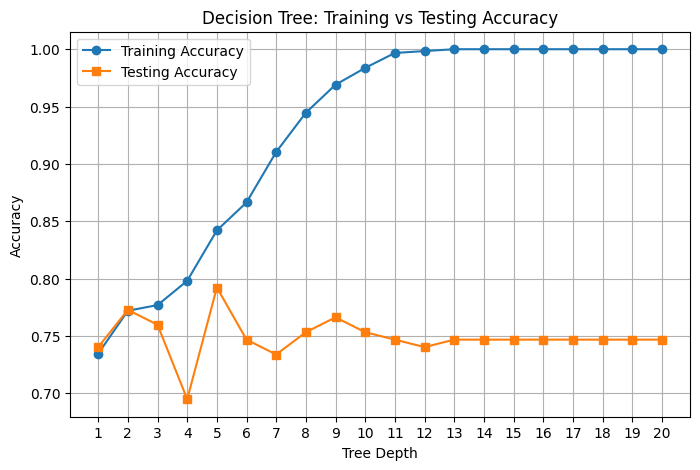

In [7]:
# Ploting Graph

plt.figure(figsize=(8,5))

plt.plot(range(1,21), train_accuracy, marker="o", label="Training Accuracy")
plt.plot(range(1,21), test_accuracy, marker="s", label="Testing Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Training vs Testing Accuracy")

plt.xticks(range(1,21))
plt.legend()

plt.grid(True)

plt.show()